In [1]:
from jax.scipy.stats import norm as jnorm
import jax.numpy as jnp
from jax import grad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [2]:
prices_raw_0 = pd.read_csv("prices_round_3_day_0.csv", sep = ";", index_col = "timestamp")
prices_raw_1 = pd.read_csv("prices_round_4_day_1.csv", sep = ";", index_col = "timestamp")
prices_raw_2 = pd.read_csv("prices_round_4_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_4_day_3.csv", sep = ";", index_col = "timestamp")

In [3]:
prices_raw_1.index = prices_raw_1.index + prices_raw_0.index.max() + 100
prices_raw_2.index = prices_raw_2.index + prices_raw_1.index.max() + 100
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw = pd.concat([prices_raw_0, prices_raw_1, prices_raw_2, prices_raw_3], axis=0)
prices_raw

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999900,3,VEV_5100,140,6,139.0,21.0,NaN,NaN,143,6,144.0,21.0,NaN,NaN,141.5,0.0
3999900,3,VEV_5200,69,6,68.0,21.0,NaN,NaN,71,27,NaN,NaN,NaN,NaN,70.0,0.0
3999900,3,VEV_5000,231,27,NaN,NaN,NaN,NaN,237,27,NaN,NaN,NaN,NaN,234.0,0.0


In [6]:
vev = prices_raw[["product", "mid_price"]]
vev

,product,mid_price
timestamp,,
0,VEV_5400,23.0
0,VEV_6500,0.5
0,VEV_5500,8.5
0,VEV_5200,101.5
0,VEV_5300,53.0
...,...,...
3999900,VEV_5100,141.5
3999900,VEV_5200,70.0
3999900,VEV_5000,234.0


In [7]:
def black_scholes(S, K, T, r, sigma, q=0, otype="call"):
  d1 = (jnp.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * jnp.sqrt(T))
  d2 = d1 - sigma * jnp.sqrt(T)
  if otype == "call":
    call = S * jnp.exp(-q * T) * jnorm.cdf(d1, 0, 1) - K * jnp.exp(-r * T) * jnorm.cdf(d2, 0, 1)
    return call 
  else:
    put = K * jnp.exp(-r * T) * jnorm.cdf(-d2, 0, 1) - S * jnp.exp(-q * T) * jnorm.cdf(-d1, 0, 1)
    return put 

In [8]:
def loss(S, K, T, r, sigma_guess, price, q=0, otype="call"):

  theoretical_price = black_scholes(S, K, T, r, sigma_guess, q, otype)

  market_price = price

  return theoretical_price - market_price

loss_grad = grad(loss, argnums=4)

In [9]:
def solve_for_iv(S, K, T, r, price, sigma_guess = 3.0, q=0, otype="call",
                N_iter = 20, epsilon = 0.001, verbose = True):
  sigma = sigma_guess
  for i in range(N_iter):
    print("\nIteration: ", i)

    loss_val = loss(S, K, T, r, sigma, price, q, otype)

    if verbose:
      print("Current Error in Theoretical vs Market Price:")
      print(loss_val)

    if abs(loss_val) < epsilon:
      break
    else:
      loss_grad_val = loss_grad(S, K, T, r, sigma, price, q, otype)

      sigma = sigma - loss_val / loss_grad_val

  return sigma

# calculated_implied_vol = solve_for_iv(S, K, T, r, price)
# print("------------------------------------")
# print("Optimised Implied Volatility: ", calculated_implied_vol)

In [10]:
def log_moneyness(S, K):
    return jnp.log(S / K)

In [11]:
# vev has index = timestamp, columns include: product, mid_price
# first move timestamp out of index so we can pivot on it
vev_wide = (
    vev.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

In [13]:
vev_wide

product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
timestamp,,,,,,,,,,,,
0,10000.0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
100,10000.0,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
200,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
300,10002.0,5250.5,1250.5,750.0,257.5,172.0,102.5,53.0,23.5,8.5,0.5,0.5
400,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
3999500,10003.0,5232.5,1232.5,732.0,234.0,142.0,70.0,26.0,5.5,1.5,0.5,0.5
3999600,9999.0,5232.5,1232.5,732.5,234.0,142.0,70.0,26.0,5.5,1.5,0.5,0.5
3999700,10001.0,5231.5,1231.5,731.0,233.0,141.0,69.0,26.0,5.5,1.5,0.5,0.5


In [14]:
S = 5250.0
K = 4000.0
T = 5.0
r = 0.0
sigma = 0.1
q = 0
otype = "call"

price = black_scholes(S, K, T, r, sigma, q, otype)
print(f"Theoretical Price: {price:.2f}")

Theoretical Price: 1305.38


In [15]:
price = 1250.0
calculated_implied_vol = solve_for_iv(S, K, T, r, price, 0.03)
print("------------------------------------")
print("Optimised Implied Volatility: ", calculated_implied_vol)


Iteration:  0
Current Error in Theoretical vs Market Price:
0.0017089844

Iteration:  1
Current Error in Theoretical vs Market Price:
0.0007324219
------------------------------------
Optimised Implied Volatility:  0.028451687


In [16]:
# vev_wide_4000["log_moneyness"] = np.log(vev_wide_4000["VELVETFRUIT_EXTRACT"] / 4000)
# vev_wide_4000["iv"] = np.nan
# for t in vev_wide.index:
#     S = vev_wide.loc[t, "VELVETFRUIT_EXTRACT"]
#     K = 4000
#     T = 5.0
#     r = 0.0
#     price = vev_wide.loc[t, "VEV_4000"]
#     iv = solve_for_iv(S, K, T, r, price, 0.03, verbose=False)
#     vev_wide_4000.loc[t, "iv"] = iv


In [17]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.cm as cm

STRIKES = {
    'VEV_4000': 4000, 'VEV_4500': 4500, 'VEV_5000': 5000,
    'VEV_5100': 5100, 'VEV_5200': 5200, 'VEV_5300': 5300,
    'VEV_5400': 5400, 'VEV_5500': 5500, 'VEV_6000': 6000,
    'VEV_6500': 6500
}

# --- BS functions (same as before) ---
def bs_price(S, K, T, sigma, r=0):
    if T <= 0: return max(S - K, 0)
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_vega(S, K, T, sigma):
    if T <= 0: return 0.0
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def compute_iv(market_price, S, K, T, tol=1e-5, max_iter=50):
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic + 1e-6 or T <= 0:
        return np.nan
    sigma = 0.3
    for _ in range(max_iter):
        p  = bs_price(S, K, T, sigma)
        v  = bs_vega(S, K, T, sigma)
        if v < 1e-10: return np.nan
        sigma -= (p - market_price) / v
        sigma  = np.clip(sigma, 0.001, 10.0)
        if abs(p - market_price) < tol: break
    return sigma if 0.01 < sigma < 5.0 else np.nan

# ── Assume df has:
#    index = timestamp (0..39999 or a day-aware index)
#    columns = ['VELVETFRUIT_EXTRACT', 'VEV_4000', ..., 'VEV_6500']
#    4 days of data → timestamps_per_day = len(df) // 4

TIMESTAMPS_PER_DAY = len(vev_wide) // 4
START_TTE = 8  # day 0 of your data = TTE 8

def ts_to_tte(ts):
    day = int(ts) // TIMESTAMPS_PER_DAY      # 0,1,2,3
    return (START_TTE - day) / 365

# ── Melt wide → long
rows = []
for voucher, K in STRIKES.items():
    tmp = vev_wide[['VELVETFRUIT_EXTRACT', voucher]].copy()
    tmp.columns = ['S', 'market_price']
    tmp['K'] = K
    tmp['voucher'] = voucher
    tmp['T'] = [ts_to_tte(ts) for ts in vev_wide.index]
    rows.append(tmp)

long = pd.concat(rows).dropna(subset=['S', 'market_price'])

# ── Compute IV (slow but readable — vectorise later if needed)
long['iv'] = [
    compute_iv(row.market_price, row.S, row.K, row.T)
    for row in long.itertuples()
]

long['log_moneyness'] = np.log(long['K'] / long['S'])
long = long.dropna(subset=['iv'])
long = long[(long['iv'] > 0.01) & (long['iv'] < 5.0)]

In [18]:
print(vev_wide[['VELVETFRUIT_EXTRACT'] + list(STRIKES.keys())].describe())

product  VELVETFRUIT_EXTRACT      VEV_4000      VEV_4500      VEV_5000  \
count           40000.000000  40000.000000  40000.000000  40000.000000   
mean             5247.364100   1247.373437    747.372962    251.673313   
std                17.090769     17.113911     17.104594     16.381336   
min              5191.500000   1189.000000    690.500000    196.500000   
25%              5236.500000   1236.500000    736.000000    241.000000   
50%              5246.500000   1246.500000    747.000000    251.500000   
75%              5259.500000   1259.500000    759.000000    263.000000   
max              5300.000000   1302.000000    800.500000    301.500000   

product      VEV_5100      VEV_5200      VEV_5300      VEV_5400      VEV_5500  \
count    40000.000000  40000.000000  40000.000000  40000.000000  40000.000000   
mean       162.674400     91.112837     43.105350     14.089150      5.545575   
std         15.326696     12.796427      8.975917      4.608139      2.476997   
min      

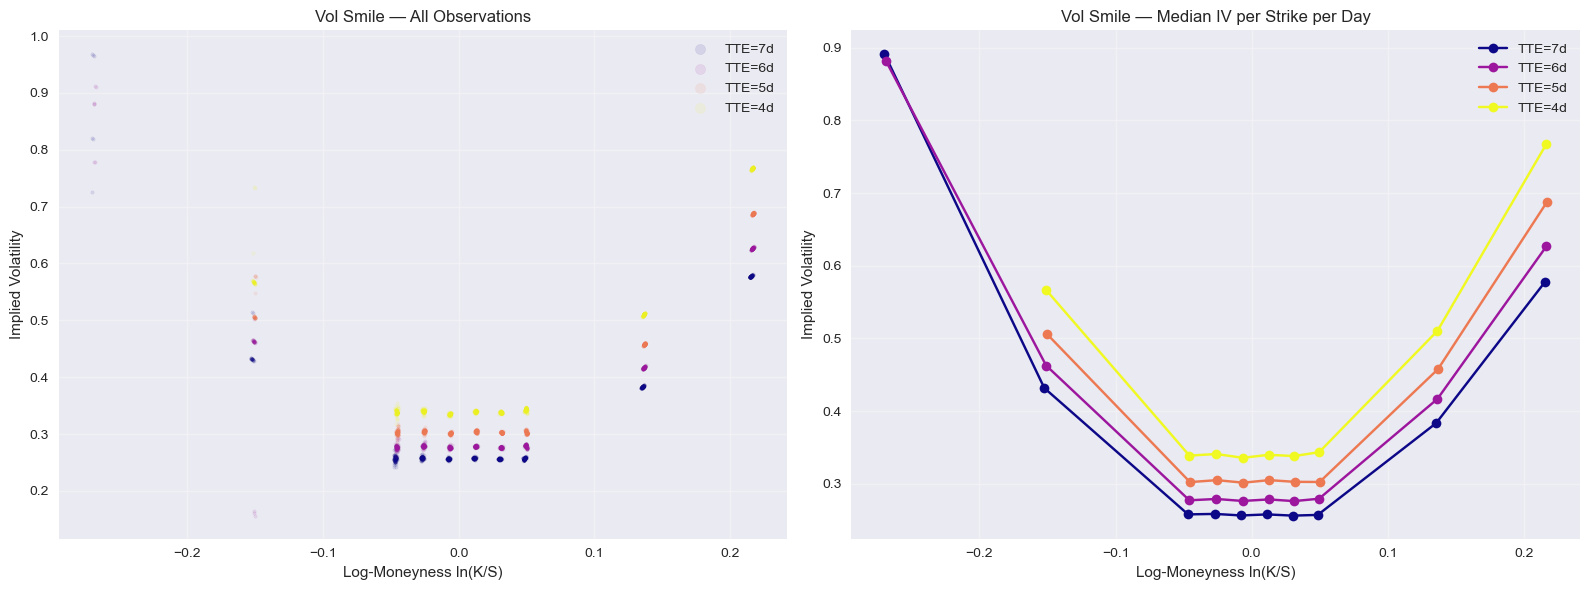

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = cm.plasma(np.linspace(0, 1, 4))  # 4 days

# Plot 1: Scatter — all observations
ax = axes[0]
for i, tte_day in enumerate([7, 6, 5, 4]):
    T = tte_day / 365
    subset = long[np.isclose(long['T'], T, atol=1e-6)]
    ax.scatter(subset['log_moneyness'], subset['iv'],
               alpha=0.1, s=6, color=colors[i], label=f'TTE={tte_day}d')
ax.set_xlabel('Log-Moneyness ln(K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title('Vol Smile — All Observations')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)

# Plot 2: Median IV per strike per day — the actual signal
ax2 = axes[1]
long['tte_day'] = (long['T'] * 365).round().astype(int)
smile = long.groupby(['tte_day', 'K'])[['iv', 'log_moneyness']].median().reset_index()

for i, tte_day in enumerate([7, 6, 5, 4]):
    subset = smile[smile['tte_day'] == tte_day]
    ax2.plot(subset['log_moneyness'], subset['iv'],
             marker='o', color=colors[i], label=f'TTE={tte_day}d')

ax2.set_xlabel('Log-Moneyness ln(K/S)')
ax2.set_ylabel('Implied Volatility')
ax2.set_title('Vol Smile — Median IV per Strike per Day')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vol_smile.png', dpi=150)
plt.show()

TTE=7d | coeffs=[ 7.53  -0.041  0.25 ] | max_resid=0.0101
TTE=6d | coeffs=[ 8.151 -0.041  0.269] | max_resid=0.0111
TTE=5d | coeffs=[ 9.    -0.049  0.294] | max_resid=0.0124
TTE=4d | coeffs=[10.032 -0.047  0.329] | max_resid=0.0135


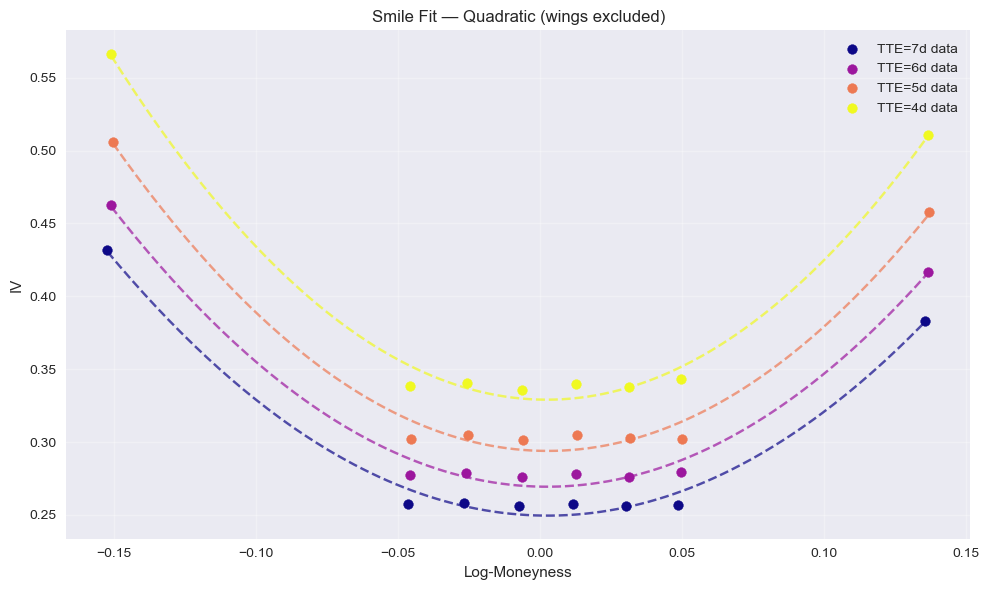

In [21]:
from numpy.polynomial import polynomial as P

fig, ax = plt.subplots(figsize=(10, 6))
colors = cm.plasma(np.linspace(0, 1, 4))

for i, tte_day in enumerate([7, 6, 5, 4]):
    subset = smile[
        (smile['tte_day'] == tte_day) &
        (smile['K'] >= 4500) &   # drop deep wings
        (smile['K'] <= 6000)
    ].sort_values('log_moneyness')
    
    x = subset['log_moneyness'].values
    y = subset['iv'].values
    
    # Fit quadratic
    coeffs = np.polyfit(x, y, deg=2)
    x_fine = np.linspace(x.min(), x.max(), 200)
    y_fit = np.polyval(coeffs, x_fine)
    
    ax.scatter(x, y, color=colors[i], zorder=5, label=f'TTE={tte_day}d data')
    ax.plot(x_fine, y_fit, color=colors[i], linestyle='--', alpha=0.7)
    
    # Print residuals
    residuals = y - np.polyval(coeffs, x)
    print(f"TTE={tte_day}d | coeffs={np.round(coeffs,3)} | max_resid={np.abs(residuals).max():.4f}")

ax.set_xlabel('Log-Moneyness')
ax.set_ylabel('IV')
ax.set_title('Smile Fit — Quadratic (wings excluded)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Print actual median IVs for ATM cluster, TTE=7
print(smile[(smile['tte_day']==7) & (smile['K'].between(5000,5400))][['K','iv','log_moneyness']])

       K        iv  log_moneyness
52  5000  0.257727      -0.046645
53  5100  0.258366      -0.026842
54  5200  0.256238      -0.007424
55  5300  0.257689       0.011624
56  5400  0.256030       0.030316
